# 01 — Análisis de datos ChEMBL (Flujo B)

Entregable 1 del curso: EDA, valores faltantes, correlación, clasificación y regresión sobre bioactividad de plaguicidas MIDA.

**Entrada:** `data/raw/chembl_panama_bioactivity.csv` (generado por `00_chembl_extraccion.ipynb`)

**Salidas:**
- `data/processed/chembl_clean.csv`
- `outputs/chembl/figures/*.png`
- `outputs/chembl/models/*.pkl`
- `outputs/chembl/results/metrics_summary.csv`

## 0. Configuración

In [1]:
import json
import sys
from pathlib import Path

import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from IPython.display import Image, display
from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor
from sklearn.metrics import (
    ConfusionMatrixDisplay,
    RocCurveDisplay,
    accuracy_score,
    classification_report,
    mean_absolute_error,
    mean_squared_error,
    r2_score,
)
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.svm import SVC, SVR
from upsetplot import UpSet

ROOT = Path.cwd().parent.parent if Path.cwd().name == "proyecto analisis de datos" else (
    Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
)
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

from src.analisis_proyecto.chembl_preprocessing import (
    ASSAY_FEATURE_COLS,
    FEATURE_COLS,
    NUMERIC_DESCRIPTOR_COLS,
    build_supervised_matrix,
    correlation_with_target,
    drop_columns_high_nan,
    encode_assay_features,
    evaluate_classification,
    evaluate_regression,
    get_available_feature_cols,
    get_feature_matrix,
    impute_median_by_family,
    load_bioactivity,
    missingness_upset_series,
    plot_missingno_report,
    numeric_and_categorical_cols,
    summary_statistics,
    train_test_split_by_group,
    train_test_split_rows,
)

sns.set_theme(style="whitegrid", palette="muted", font_scale=1.05)
plt.rcParams.update({"figure.figsize": (10, 5), "figure.dpi": 120})

RAW_CSV = ROOT / "data" / "raw" / "chembl_panama_bioactivity.csv"
CLEAN_CSV = ROOT / "data" / "processed" / "chembl_clean.csv"
FIG_DIR = ROOT / "outputs" / "chembl" / "figures"
MODEL_DIR = ROOT / "outputs" / "chembl" / "models"
RESULTS_DIR = ROOT / "outputs" / "chembl" / "results"

for d in (FIG_DIR, MODEL_DIR, RESULTS_DIR, CLEAN_CSV.parent):
    d.mkdir(parents=True, exist_ok=True)

RANDOM_STATE = 42
NAN_COL_THRESHOLD = 250

assert RAW_CSV.exists(), (
    f"No se encontró {RAW_CSV}. Ejecuta primero 00_chembl_extraccion.ipynb"
)

df = load_bioactivity(RAW_CSV)
print(f"Dataset cargado: {df.shape[0]:,} filas × {df.shape[1]} columnas")
print(f"Compuestos: {df['compound_name'].nunique()}")

Dataset cargado: 3,608 filas × 36 columnas
Compuestos: 107


## 1. Análisis preliminar

Medidas de tendencia central, distribuciones y conteos categóricos.

In [2]:
eda_numeric = [c for c in NUMERIC_DESCRIPTOR_COLS if c in df.columns]
display(df[eda_numeric].describe().T)

stats_table = summary_statistics(df, eda_numeric)
display(stats_table.round(4))

,count,mean,std,min,25%,50%,75%,max
mw_freebase,3608.0,276.661042,108.902180,30.030,170.12,350.59,375.87,427.25
alogp,3608.0,2.644753,1.988320,-3.720,0.80,3.93,4.43,4.72
psa,3608.0,54.202350,23.890201,0.000,40.54,40.62,68.53,167.91
hba,3608.0,3.177661,1.377179,0.000,2.00,3.00,4.00,9.00
hbd,3608.0,1.137749,0.953964,0.000,1.00,1.00,1.00,7.00
aromatic_rings,3608.0,1.715078,0.948216,0.000,1.00,2.00,2.00,3.00
heavy_atoms,3608.0,19.094789,7.578836,1.000,12.00,23.00,26.00,27.00
rtb,3608.0,3.611142,2.287939,0.000,1.00,4.00,6.00,9.00
num_ro5_violations,3608.0,0.000554,0.023541,0.000,0.00,0.00,0.00,1.00
cx_logp,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN


,columna,media,mediana,moda,desv_std,n
0,mw_freebase,276.6610,350.59,375.87,108.9022,3608
1,alogp,2.6448,3.93,4.43,1.9883,3608
2,psa,54.2024,40.62,40.54,23.8902,3608
3,hba,3.1777,3.00,3.00,1.3772,3608
4,hbd,1.1377,1.00,1.00,0.9540,3608
5,aromatic_rings,1.7151,2.00,2.00,0.9482,3608
6,heavy_atoms,19.0948,23.00,26.00,7.5788,3608
7,rtb,3.6111,4.00,6.00,2.2879,3608
8,num_ro5_violations,0.0006,0.00,0.00,0.0235,3608
9,pchembl_value,6.2397,6.00,7.11,1.5585,3608


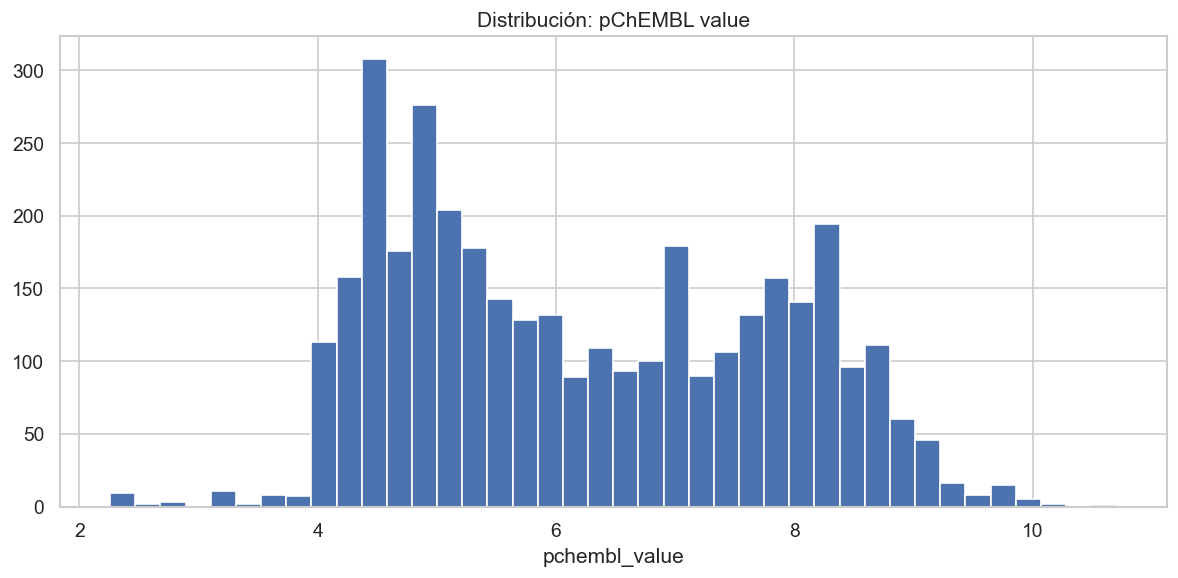

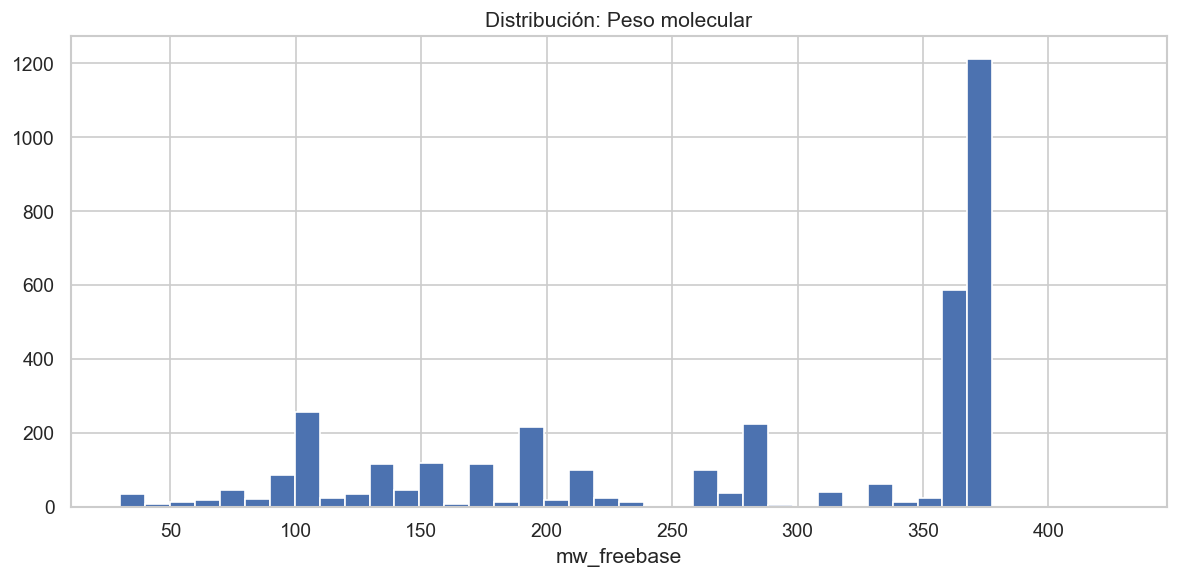

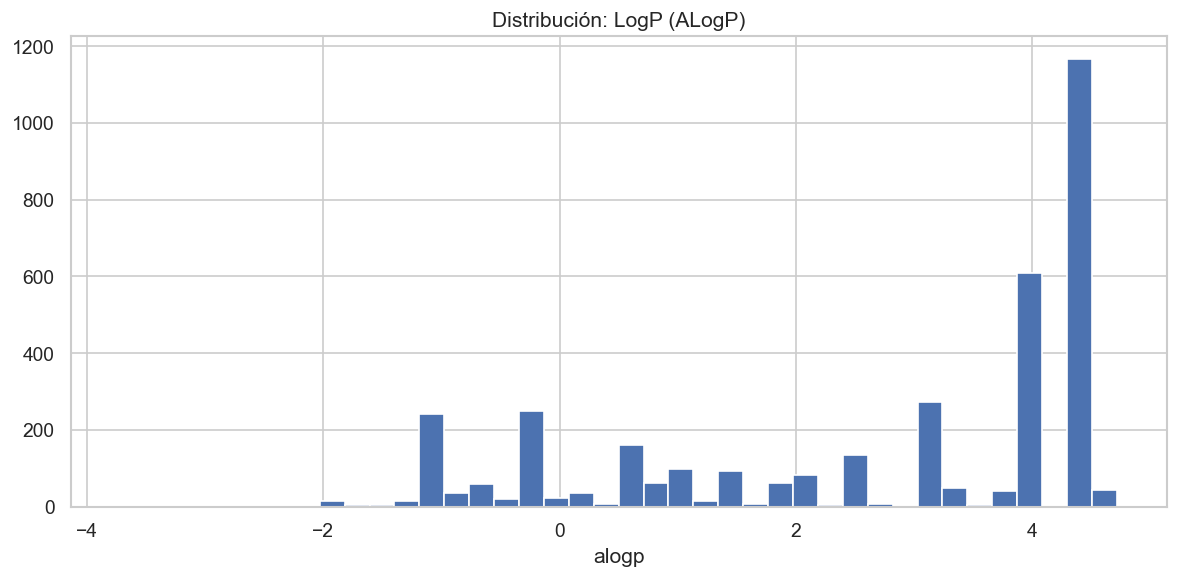

In [3]:
for col, title in [
    ("pchembl_value", "pChEMBL value"),
    ("mw_freebase", "Peso molecular"),
    ("alogp", "LogP (ALogP)"),
]:
    if col not in df.columns:
        continue
    fig, ax = plt.subplots()
    df[col].dropna().hist(bins=40, ax=ax, edgecolor="white", color="#4C72B0")
    ax.set_title(f"Distribución: {title}")
    ax.set_xlabel(col)
    plt.tight_layout()
    plt.savefig(FIG_DIR / f"hist_{col}.png", bbox_inches="tight")
    plt.show()

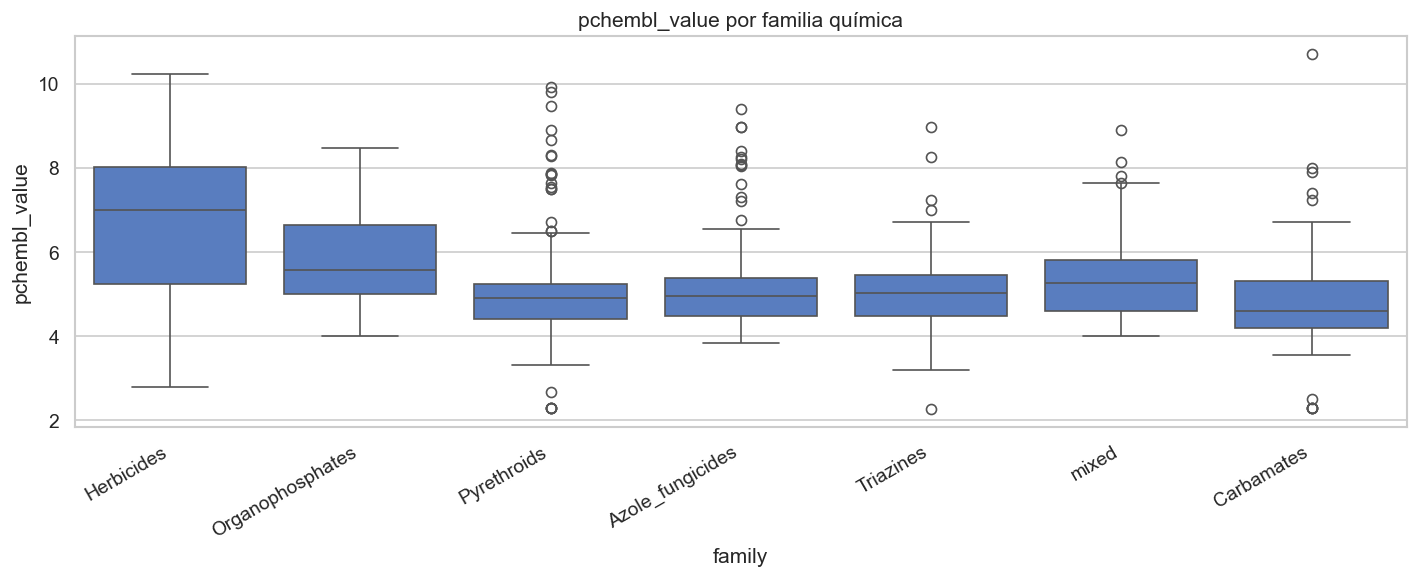

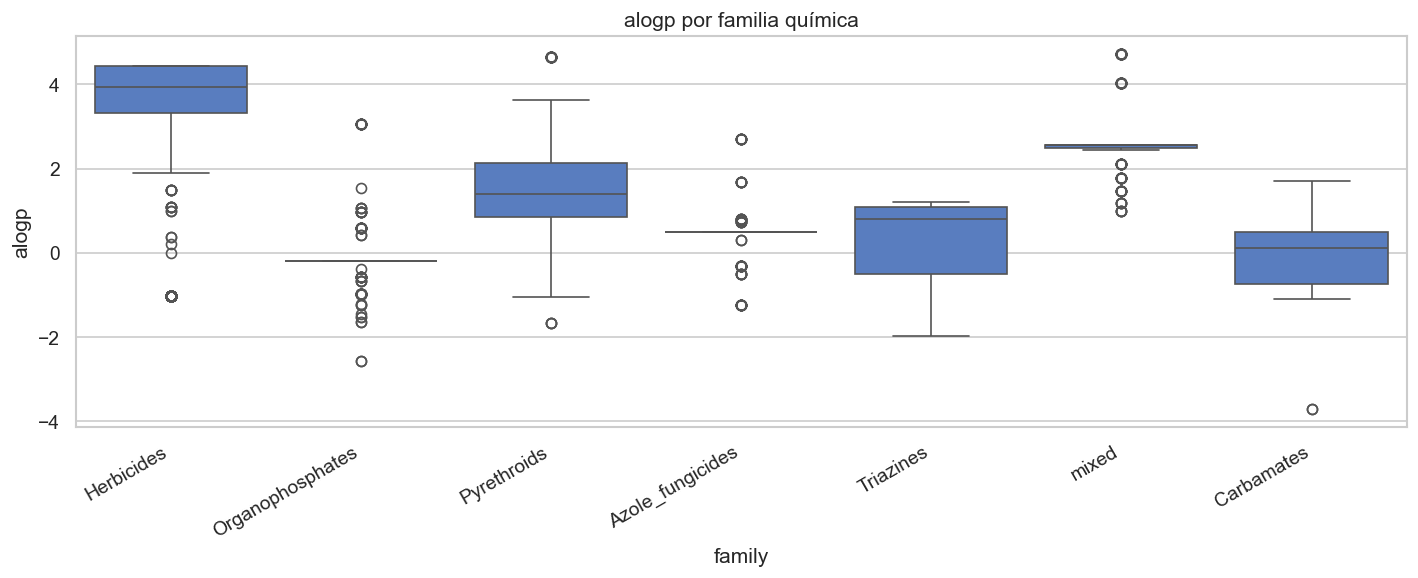


=== activity_class ===


,n
activity_class,
Active,1810
Inactive,1737
NaN,61



=== assay_type ===


,n
assay_type,
B,2514
F,970
A,116
P,7
T,1



=== standard_type ===


,n
standard_type,
Ki,1411
IC50,1276
Potency,503
EC50,168
AC50,124
Kd,65
MIC,39
ED50,10
LD50,4



=== target_type ===


,n
target_type,
SINGLE PROTEIN,2415
UNCHECKED,351
CELL-LINE,209
PROTEIN FAMILY,146
ORGANISM,123
PROTEIN COMPLEX GROUP,116
PROTEIN COMPLEX,116
NON-MOLECULAR,56
UNKNOWN,27


In [4]:
for col in ["pchembl_value", "alogp"]:
    if col not in df.columns:
        continue
    fig, ax = plt.subplots(figsize=(12, 5))
    sns.boxplot(data=df, x="family", y=col, ax=ax)
    ax.set_title(f"{col} por familia química")
    plt.xticks(rotation=30, ha="right")
    plt.tight_layout()
    plt.savefig(FIG_DIR / f"box_{col}_by_family.png", bbox_inches="tight")
    plt.show()

for cat_col in ["activity_class", "assay_type", "standard_type", "target_type"]:
    if cat_col not in df.columns:
        continue
    print(f"\n=== {cat_col} ===")
    display(df[cat_col].value_counts(dropna=False).to_frame("n"))

## 2. Valores faltantes e imputación

- Visualización con **missingno** y **UpSetPlot**
- Eliminar columnas con más de 250 NaN
- Imputar numéricas: **mediana por `family`** (fallback global)

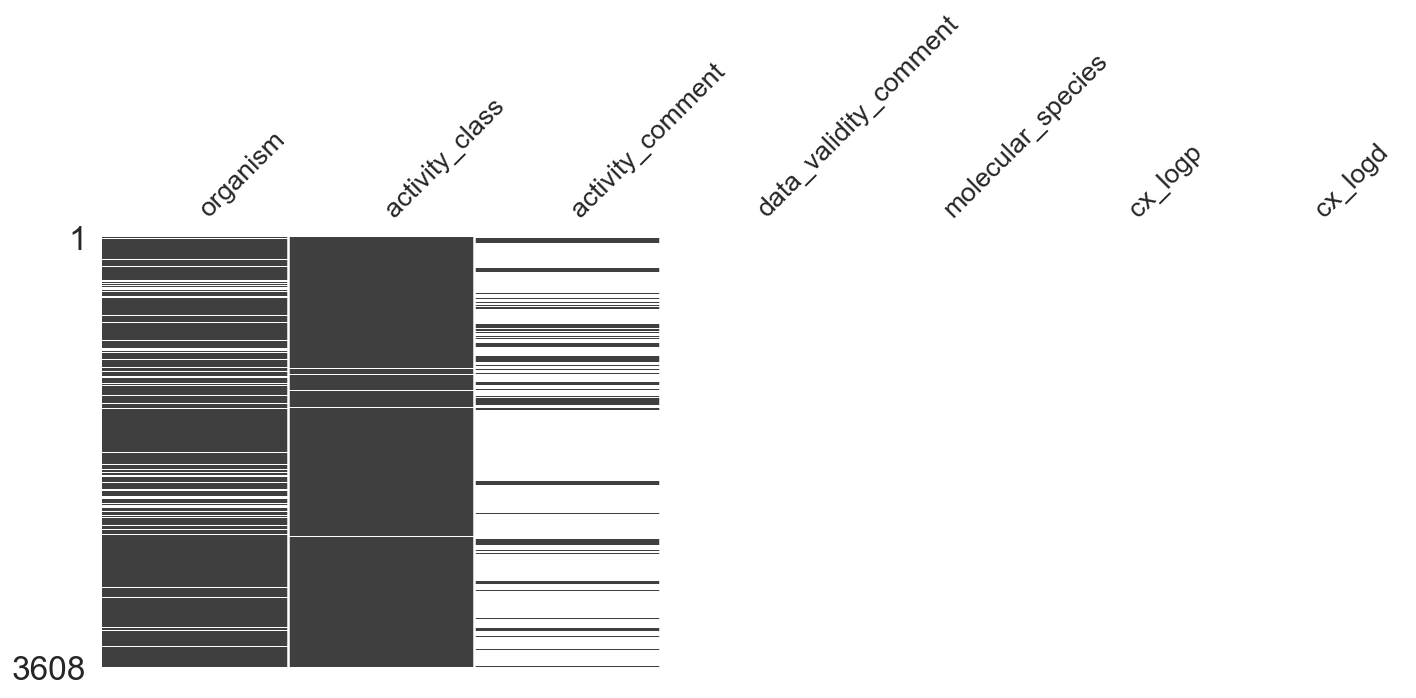

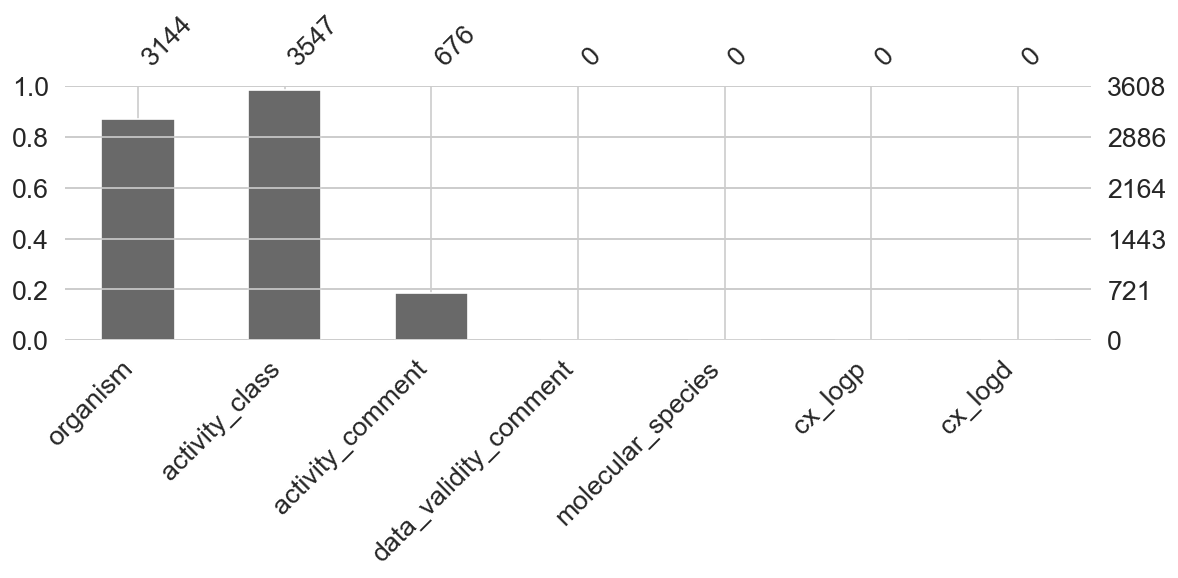

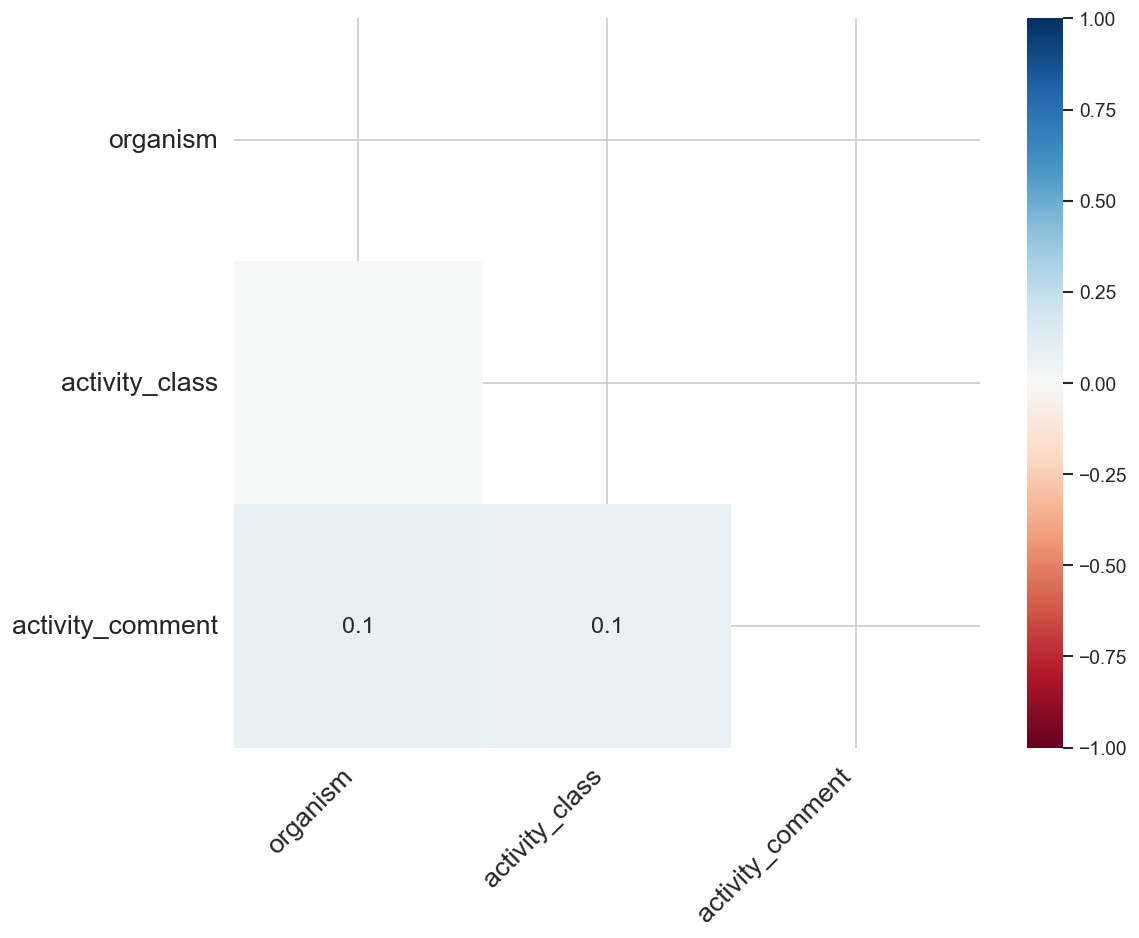

In [5]:
saved_msno = plot_missingno_report(df, FIG_DIR)
if saved_msno:
    for path in saved_msno:
        display(Image(filename=str(path)))
else:
    print("Sin valores faltantes — no se generan gráficos missingno.")

c:\Users\mateo\Desktop\JIC2026\.venv\lib\site-packages\upsetplot\plotting.py:795: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  styles["linewidth"].fillna(1, inplace=True)
c:\Users\mateo\Desktop\JIC2026\.venv\lib\site-packages\upsetplot\plotting.py:796: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always be

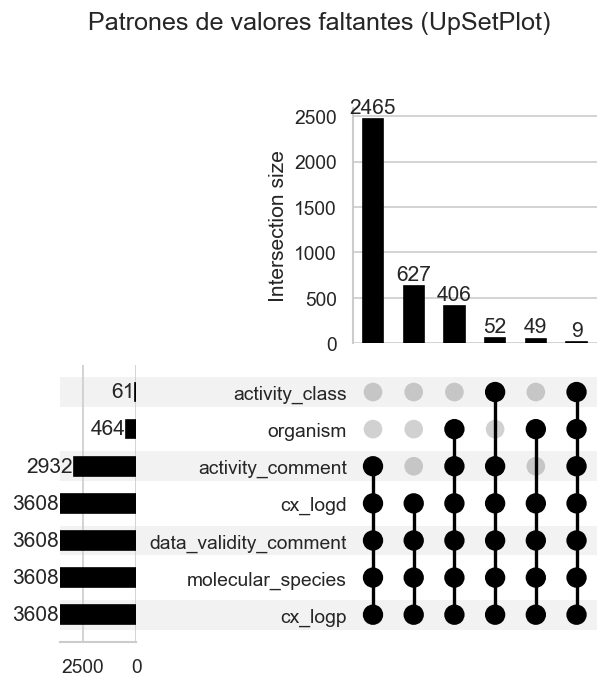

In [6]:
upset_data, nan_cols = missingness_upset_series(df)
if upset_data is not None:
    # Varios registros comparten el mismo patrón de NaN → subset_size="count"
    upset = UpSet(upset_data, show_counts=True, sort_by="cardinality", subset_size="count")
    upset.plot()
    plt.suptitle("Patrones de valores faltantes (UpSetPlot)", y=1.02)
    plt.savefig(FIG_DIR / "upset_missing.png", bbox_inches="tight")
    plt.show()
else:
    print("Sin valores faltantes para UpSetPlot.")

In [7]:
df_dropped, nan_report = drop_columns_high_nan(df, threshold=NAN_COL_THRESHOLD)
dropped_cols = nan_report.query("decision == 'eliminar'")["columna"].tolist()
print(f"Columnas eliminadas (>{NAN_COL_THRESHOLD} NaN): {dropped_cols}")
display(nan_report)

num_cols, cat_cols = numeric_and_categorical_cols(df_dropped)
df_clean = impute_median_by_family(df_dropped, numeric_cols=num_cols, categorical_cols=cat_cols)

remaining_nan = df_clean.isna().sum()
print("\nNaN restantes por columna (features de modelado):")
feat_nan = remaining_nan[get_available_feature_cols(df_clean) + ["activity_class", "pchembl_value"]]
display(feat_nan[feat_nan > 0].to_frame("n_nan") if (feat_nan > 0).any() else pd.DataFrame({"ok": ["Sin NaN en columnas clave"]}))

df_clean.to_csv(CLEAN_CSV, index=False)
print(f"\nGuardado: {CLEAN_CSV} ({len(df_clean):,} filas)")

Columnas eliminadas (>250 NaN): ['data_validity_comment', 'molecular_species', 'cx_logd', 'cx_logp', 'activity_comment', 'organism']


,columna,n_nan,pct_nan,decision
20,data_validity_comment,3608,100.00,eliminar
33,molecular_species,3608,100.00,eliminar
35,cx_logd,3608,100.00,eliminar
34,cx_logp,3608,100.00,eliminar
19,activity_comment,2932,81.26,eliminar
11,organism,464,12.86,eliminar
18,activity_class,61,1.69,conservar
0,compound_name,0,0.00,conservar
3,smiles,0,0.00,conservar
2,chembl_id,0,0.00,conservar



NaN restantes por columna (features de modelado):


,ok
0,Sin NaN en columnas clave



Guardado: c:\Users\mateo\Desktop\JIC2026\data\processed\chembl_clean.csv (3,608 filas)


## 3. Correlación

Pearson y Spearman vs `pchembl_value`; heatmap y pairplot de variables top.

,variable,pearson,spearman,n
6,heavy_atoms,0.5022,0.5540,3608
0,mw_freebase,0.4951,0.5539,3608
1,alogp,0.4978,0.5419,3608
7,rtb,0.4530,0.4808,3608
2,psa,-0.2375,-0.2563,3608
5,aromatic_rings,0.2496,0.2422,3608
3,hba,-0.0944,-0.0612,3608
4,hbd,-0.1385,-0.0459,3608
8,num_ro5_violations,-0.0292,-0.0349,3608


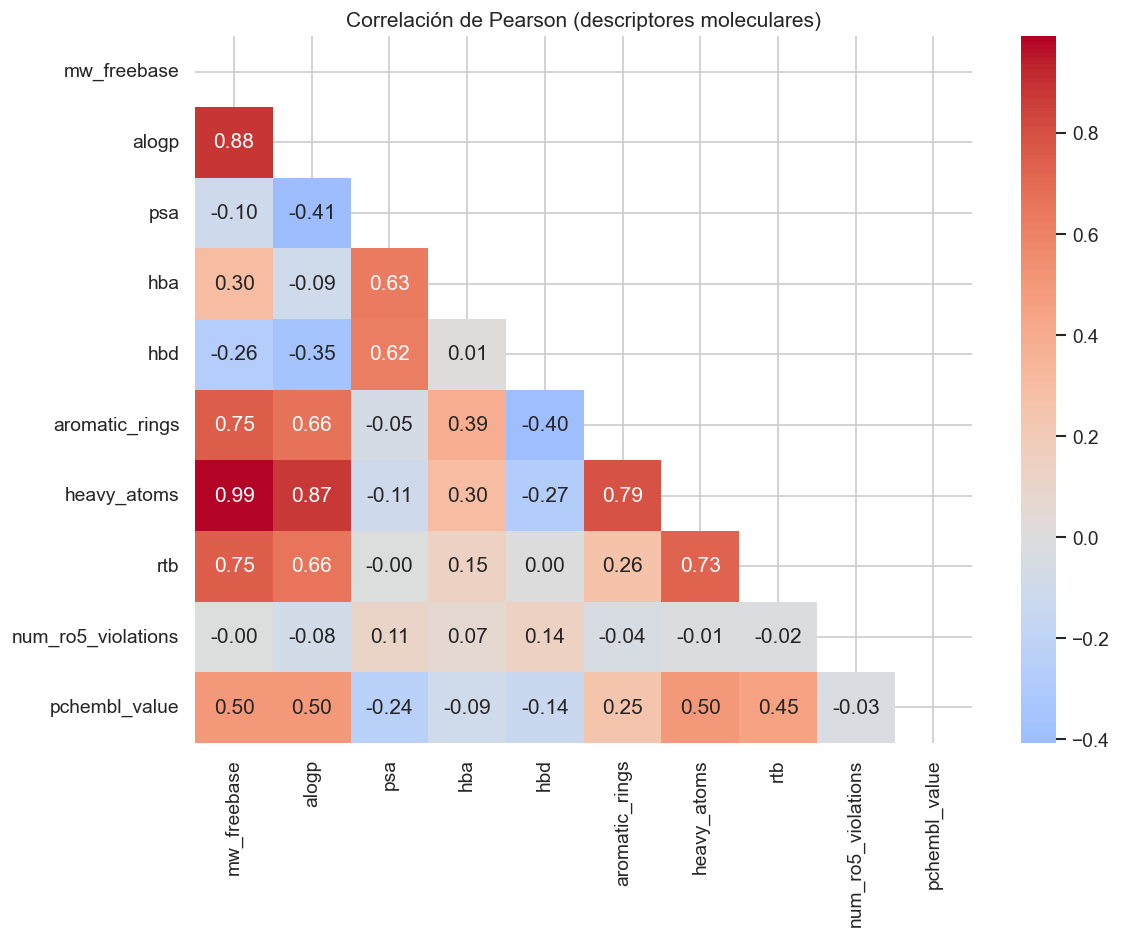

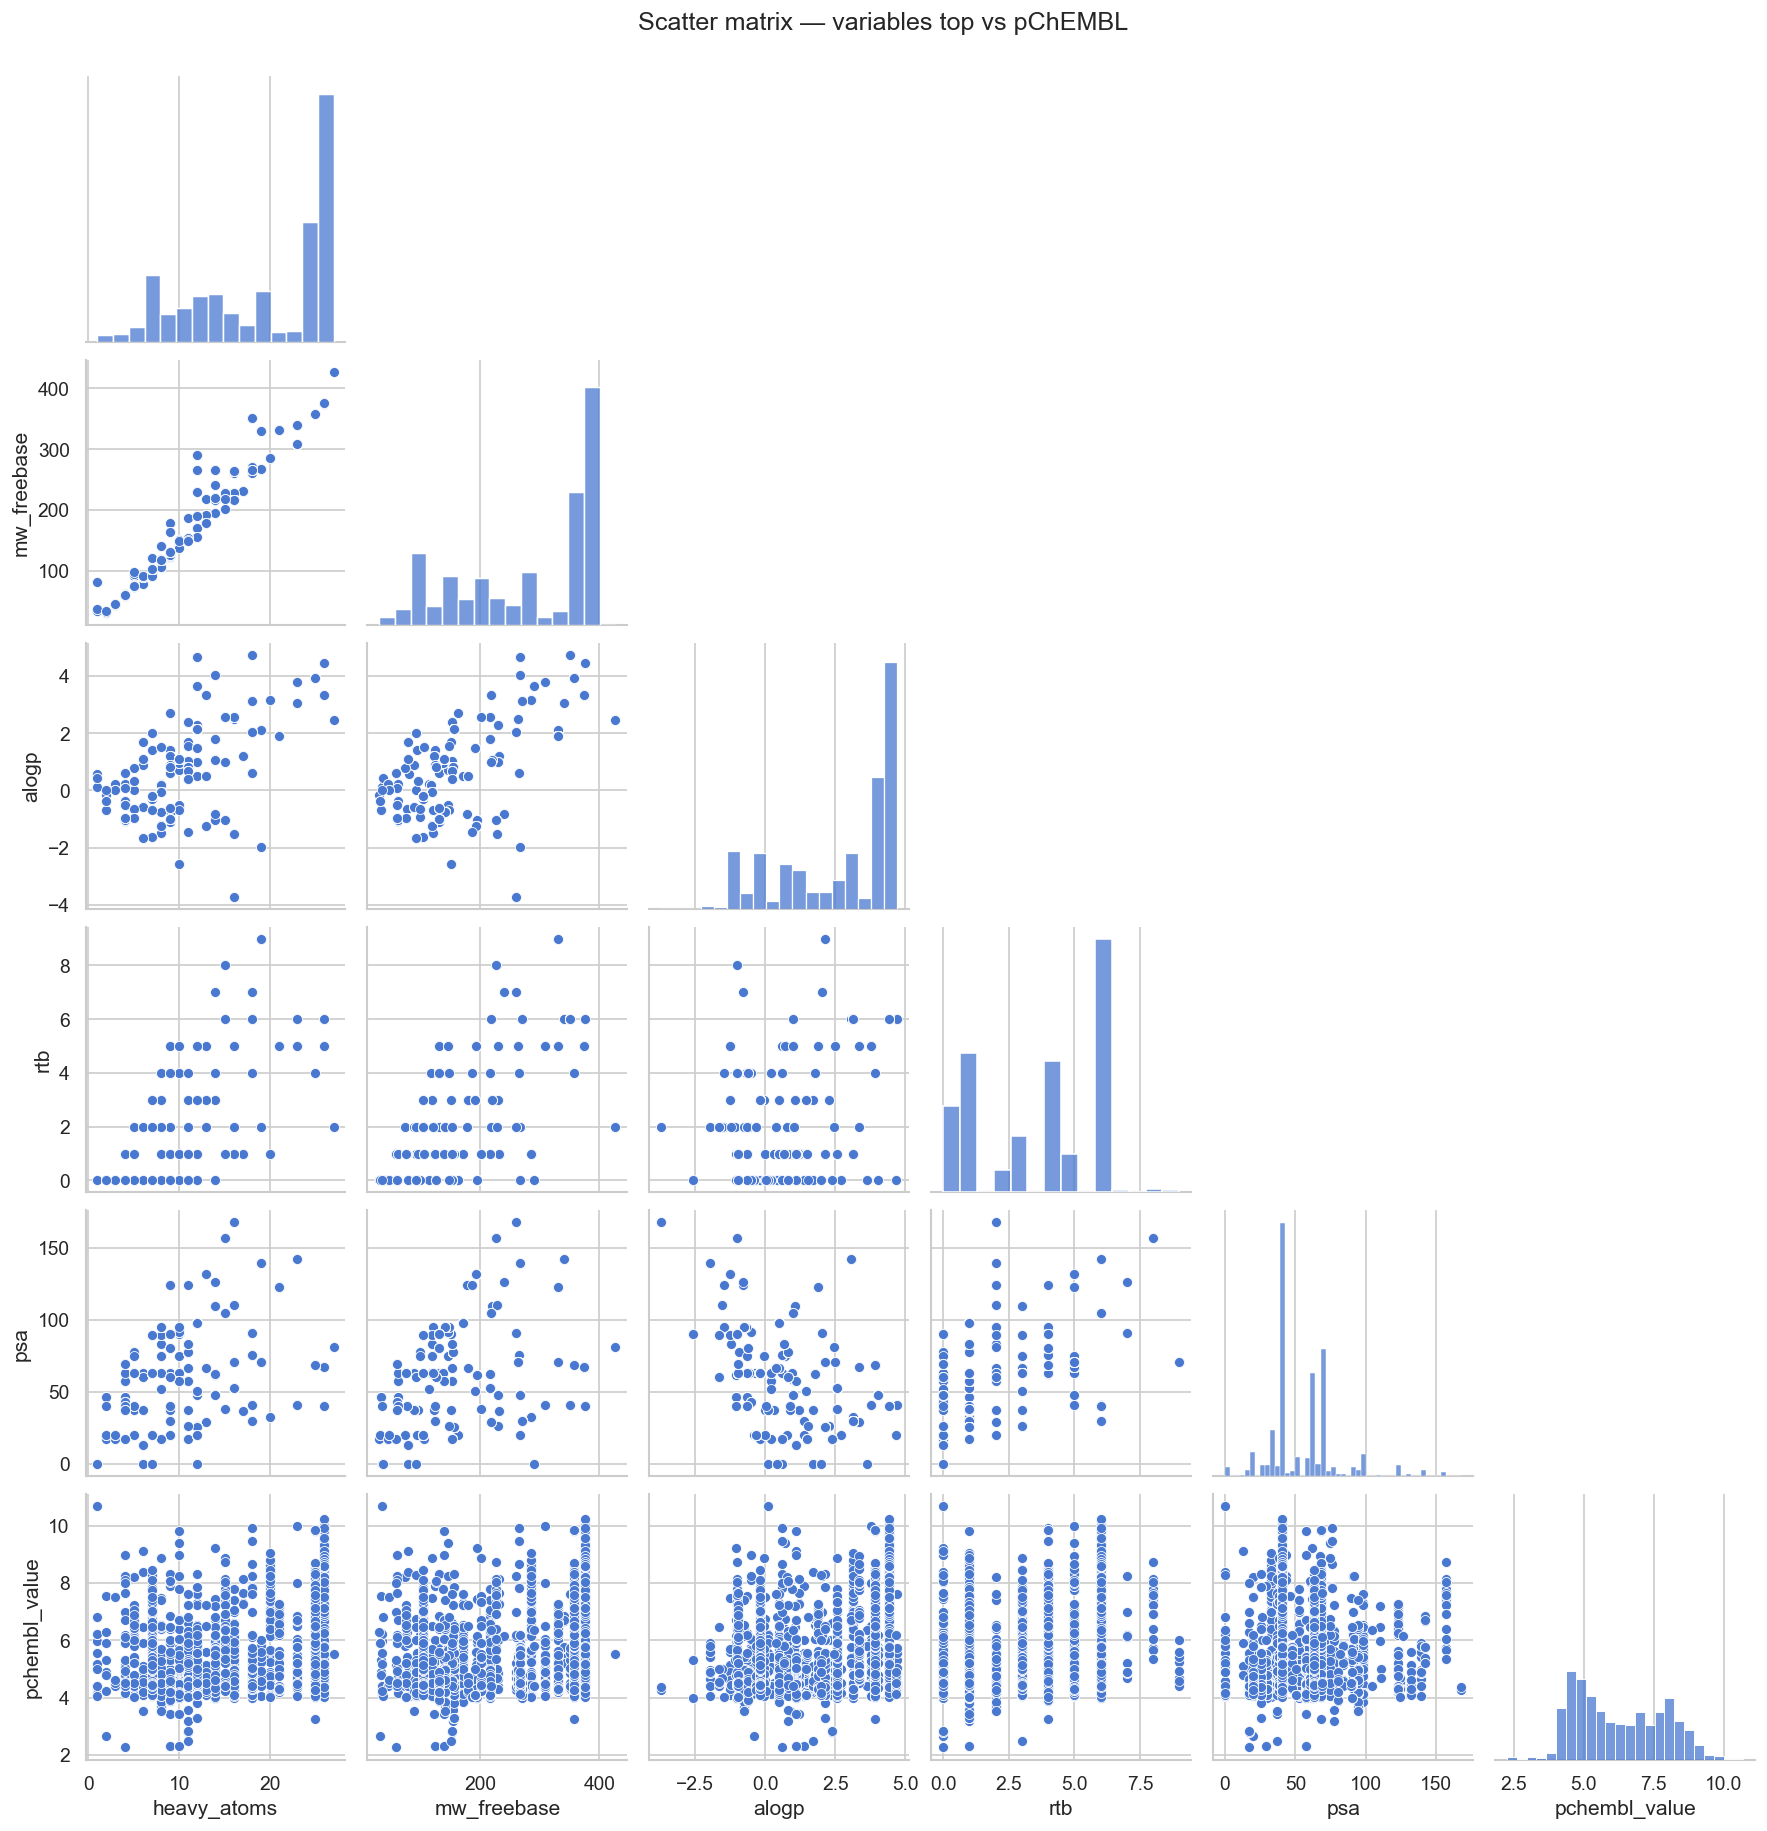

In [8]:
corr_cols = [c for c in get_available_feature_cols(df_clean) if c in df_clean.columns]
corr_table = correlation_with_target(df_clean, columns=corr_cols)
display(corr_table.round(4))

if len(corr_cols) >= 2:
    corr_matrix = df_clean[corr_cols + ["pchembl_value"]].corr(method="pearson")
    mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
    fig, ax = plt.subplots(figsize=(10, 8))
    sns.heatmap(corr_matrix, mask=mask, annot=True, fmt=".2f", cmap="coolwarm", center=0, ax=ax)
    ax.set_title("Correlación de Pearson (descriptores moleculares)")
    plt.tight_layout()
    plt.savefig(FIG_DIR / "correlation_heatmap.png", bbox_inches="tight")
    plt.show()

top_vars = corr_table.head(5)["variable"].tolist() if not corr_table.empty else corr_cols[:4]
pair_cols = list(dict.fromkeys(top_vars + ["pchembl_value"]))
if len(pair_cols) >= 2:
    g = sns.pairplot(df_clean[pair_cols].dropna(), diag_kind="hist", corner=True)
    g.fig.suptitle("Scatter matrix — variables top vs pChEMBL", y=1.02)
    g.savefig(FIG_DIR / "correlation_pairplot.png", bbox_inches="tight")
    plt.show()

## 4. Clasificación

**Objetivo:** `activity_class` (Active / Inactive)  
**Features:** descriptores moleculares (+ opcional contexto de ensayo en evaluación)  
**Splits evaluados:**
- **Por filas (80/20):** métrica estándar del curso
- **Por compuesto:** generalización a plaguicidas no vistos (misma molécula no en train y test)

Features moleculares (9): ['mw_freebase', 'alogp', 'psa', 'hba', 'hbd', 'aromatic_rings', 'heavy_atoms', 'rtb', 'num_ro5_violations']

Muestras clasificación: 3,608
Compuestos únicos: 107
activity_class
Active      1871
Inactive    1737
Name: count, dtype: int64

=== RandomForest (split filas) ===
Accuracy train: 0.7758 | test: 0.7576
              precision    recall  f1-score   support

      Active       0.72      0.87      0.79       374
    Inactive       0.82      0.64      0.72       348

    accuracy                           0.76       722
   macro avg       0.77      0.75      0.75       722
weighted avg       0.77      0.76      0.75       722


=== SVM_RBF (split filas) ===
Accuracy train: 0.7661 | test: 0.7521
              precision    recall  f1-score   support

      Active       0.73      0.84      0.78       374
    Inactive       0.79      0.66      0.72       348

    accuracy                           0.75       722
   macro avg       0.76      0.75      0.75      

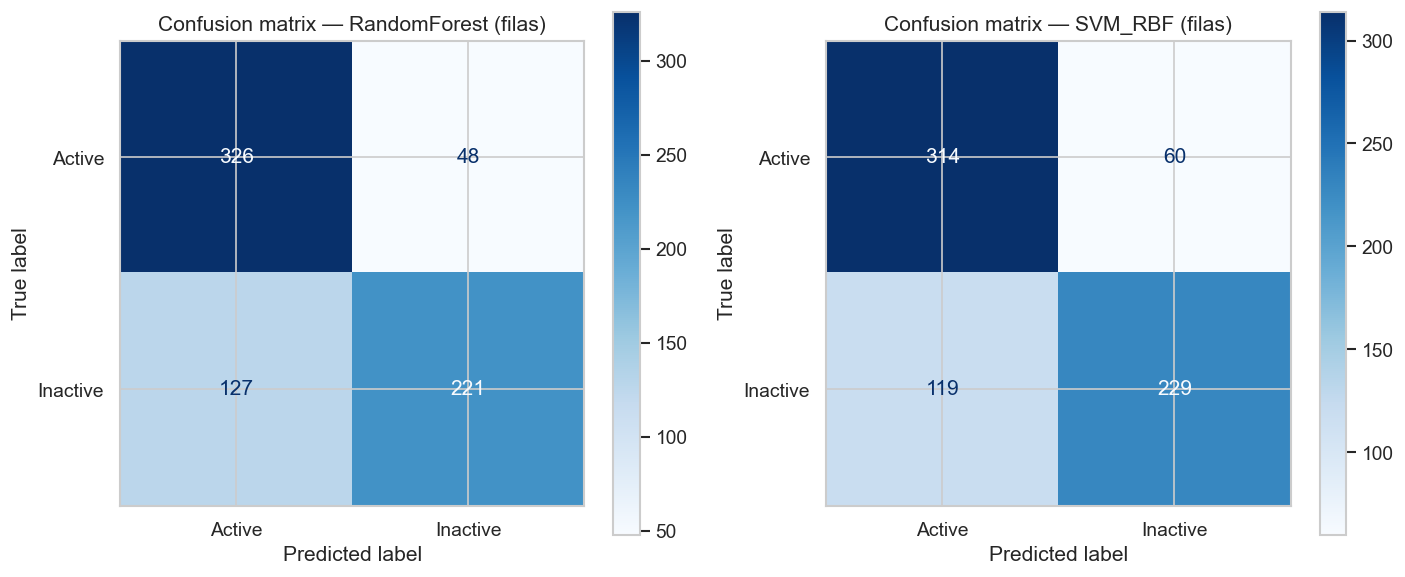

c:\Users\mateo\Desktop\JIC2026\.venv\lib\site-packages\sklearn\metrics\_ranking.py:1201: UndefinedMetricWarning: No positive samples in y_true, true positive value should be meaningless
  warnings.warn(
c:\Users\mateo\Desktop\JIC2026\.venv\lib\site-packages\sklearn\metrics\_ranking.py:1201: UndefinedMetricWarning: No positive samples in y_true, true positive value should be meaningless
  warnings.warn(


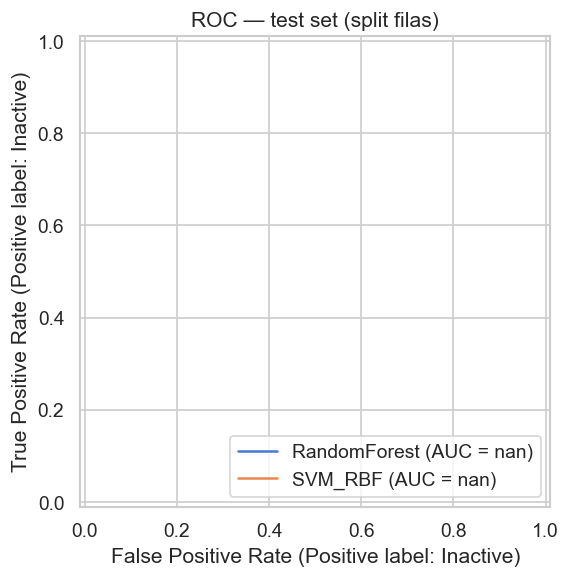

Modelos guardados en c:\Users\mateo\Desktop\JIC2026\outputs\chembl\models


In [9]:
feature_cols = get_available_feature_cols(df_clean)
print(f"Features moleculares ({len(feature_cols)}): {feature_cols}")

X_all, y_class_all, groups_cls = build_supervised_matrix(
    df_clean,
    target_col="activity_class",
    numeric_cols=feature_cols,
    include_assay_features=False,
)

print(f"\nMuestras clasificación: {len(X_all):,}")
print(f"Compuestos únicos: {groups_cls.nunique()}")
print(y_class_all.value_counts())

# --- Split por filas (referencia curso) ---
X_train_c, X_test_c, y_train_c, y_test_c = train_test_split_rows(
    X_all, y_class_all, test_size=0.2, random_state=RANDOM_STATE, stratify=True
)

rf_clf = RandomForestClassifier(
    n_estimators=100, random_state=RANDOM_STATE, class_weight="balanced", n_jobs=-1
)
rf_clf.fit(X_train_c, y_train_c)

svm_clf = Pipeline([
    ("scaler", StandardScaler()),
    ("svc", SVC(kernel="rbf", probability=True, class_weight="balanced", random_state=RANDOM_STATE)),
])
svm_clf.fit(X_train_c, y_train_c)

cls_metrics = []
for name, model in [("RandomForest", rf_clf), ("SVM_RBF", svm_clf)]:
    scores = evaluate_classification(model, X_train_c, X_test_c, y_train_c, y_test_c)
    cls_metrics.append({
        "modelo": name,
        "tarea": "clasificacion",
        "split": "filas",
        "feature_set": "descriptores",
        **scores,
    })
    print(f"\n=== {name} (split filas) ===")
    print(f"Accuracy train: {scores['accuracy_train']:.4f} | test: {scores['accuracy_test']:.4f}")
    print(classification_report(y_test_c, model.predict(X_test_c)))

# --- Split por compuesto (generalización) ---
X_tr_g, X_te_g, y_tr_g, y_te_g = train_test_split_by_group(
    X_all, y_class_all, groups_cls, test_size=0.2, random_state=RANDOM_STATE
)
rf_group = RandomForestClassifier(
    n_estimators=100, random_state=RANDOM_STATE, class_weight="balanced", n_jobs=-1
)
rf_group.fit(X_tr_g, y_tr_g)
scores_g = evaluate_classification(rf_group, X_tr_g, X_te_g, y_tr_g, y_te_g)
cls_metrics.append({
    "modelo": "RandomForest",
    "tarea": "clasificacion",
    "split": "compuesto",
    "feature_set": "descriptores",
    **scores_g,
})
print(f"\n=== RandomForest (split compuesto) ===")
print(f"Accuracy train: {scores_g['accuracy_train']:.4f} | test: {scores_g['accuracy_test']:.4f}")
print(f"Compuestos en test: {groups_cls.loc[X_te_g.index].nunique()}")

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
for ax, (name, model) in zip(axes, [("RandomForest", rf_clf), ("SVM_RBF", svm_clf)]):
    ConfusionMatrixDisplay.from_estimator(model, X_test_c, y_test_c, ax=ax, cmap="Blues")
    ax.set_title(f"Confusion matrix — {name} (filas)")
plt.tight_layout()
plt.savefig(FIG_DIR / "confusion_matrices.png", bbox_inches="tight")
plt.show()

fig, ax = plt.subplots()
le = LabelEncoder()
le.fit(["Inactive", "Active"])
y_bin = le.transform(y_test_c)
RocCurveDisplay.from_estimator(rf_clf, X_test_c, y_bin, name="RandomForest", ax=ax)
RocCurveDisplay.from_estimator(svm_clf, X_test_c, y_bin, name="SVM_RBF", ax=ax)
ax.set_title("ROC — test set (split filas)")
plt.tight_layout()
plt.savefig(FIG_DIR / "roc_curves.png", bbox_inches="tight")
plt.show()

joblib.dump(rf_clf, MODEL_DIR / "rf_classifier.pkl")
joblib.dump(svm_clf, MODEL_DIR / "svm_classifier.pkl")
with open(MODEL_DIR / "feature_cols.json", "w", encoding="utf-8") as f:
    json.dump(feature_cols, f, indent=2)
print(f"Modelos guardados en {MODEL_DIR}")

## 5. Regresión

**Objetivo:** `pchembl_value`  
**Modelos:** SVR (RBF) y Random Forest Regressor  

Se comparan dos conjuntos de features y dos protocolos de split:

| Config | Features | Split | Interpretación |
|--------|----------|-------|----------------|
| A | Descriptores moleculares | Por filas | Referencia del curso (puede inflar R²) |
| B | Descriptores moleculares | Por compuesto | Generalización química real |
| C | Descriptores + ensayo | Por filas | Mejor ajuste (incluye diana/tipo de medida) |
| D | Descriptores + ensayo | Por compuesto | Evaluación más honesta |

**Métricas:** R² train/test, MAE, RMSE, scatter predicho vs real

,modelo,tarea,split,feature_set,n_train,n_test,r2_train,r2_test,mae_test,rmse_test
0,SVR_RBF,regresion,filas,descriptores,2886,722,0.4736,0.4996,0.8163,1.1092
1,RandomForest,regresion,filas,descriptores,2886,722,0.5082,0.5097,0.8358,1.0981
2,SVR_RBF,regresion,compuesto,descriptores,3207,401,0.4652,-1.0253,1.9917,2.3073
3,RandomForest,regresion,compuesto,descriptores,3207,401,0.4996,0.0322,1.4259,1.5950
4,SVR_RBF,regresion,filas,descriptores+ensayo,2886,722,0.6259,0.5742,0.6834,1.0232
5,RandomForest,regresion,filas,descriptores+ensayo,2886,722,0.7224,0.6152,0.6732,0.9727
6,SVR_RBF,regresion,compuesto,descriptores+ensayo,3207,401,0.6190,-0.2436,1.5056,1.8081
7,RandomForest,regresion,compuesto,descriptores+ensayo,3207,401,0.7075,0.1686,1.2461,1.4783


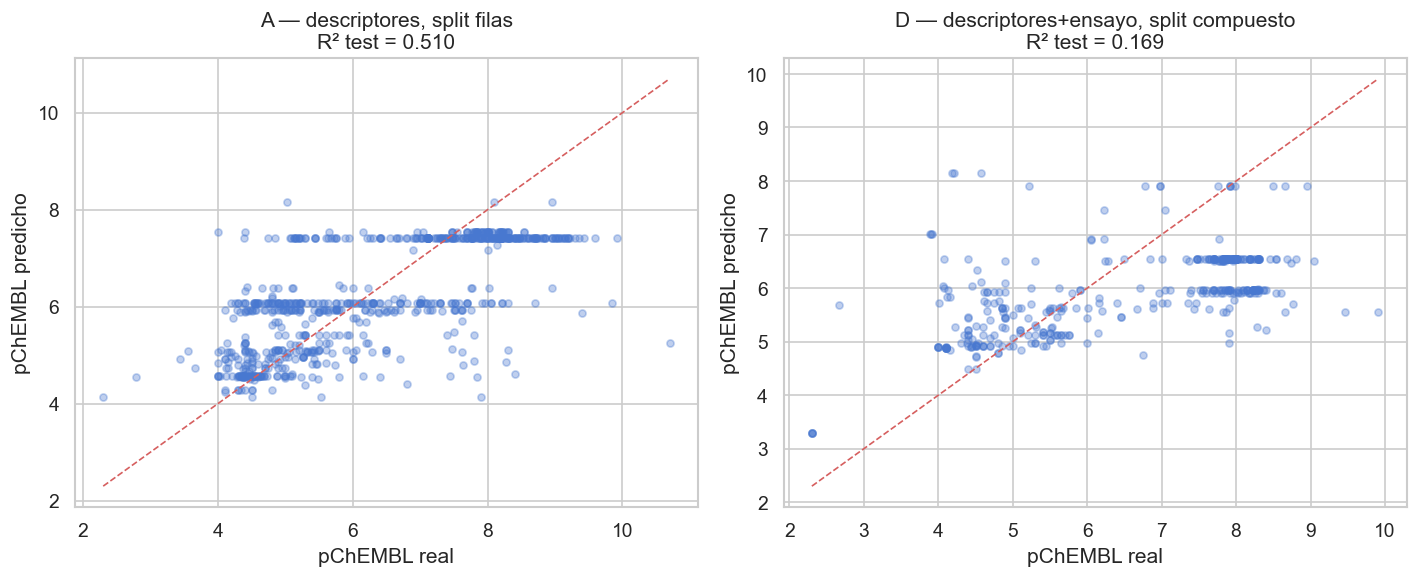

,modelo,tarea,split,feature_set,accuracy_train,accuracy_test,n_train,n_test,r2_train,r2_test,mae_test,rmse_test
0,RandomForest,clasificacion,filas,descriptores,0.7758,0.7576,NaN,NaN,NaN,NaN,NaN,NaN
1,SVM_RBF,clasificacion,filas,descriptores,0.7661,0.7521,NaN,NaN,NaN,NaN,NaN,NaN
2,RandomForest,clasificacion,compuesto,descriptores,0.7643,0.3791,NaN,NaN,NaN,NaN,NaN,NaN
3,SVR_RBF,regresion,filas,descriptores,NaN,NaN,2886.0,722.0,0.4736,0.4996,0.8163,1.1092
4,RandomForest,regresion,filas,descriptores,NaN,NaN,2886.0,722.0,0.5082,0.5097,0.8358,1.0981
5,SVR_RBF,regresion,compuesto,descriptores,NaN,NaN,3207.0,401.0,0.4652,-1.0253,1.9917,2.3073
6,RandomForest,regresion,compuesto,descriptores,NaN,NaN,3207.0,401.0,0.4996,0.0322,1.4259,1.5950
7,SVR_RBF,regresion,filas,descriptores+ensayo,NaN,NaN,2886.0,722.0,0.6259,0.5742,0.6834,1.0232
8,RandomForest,regresion,filas,descriptores+ensayo,NaN,NaN,2886.0,722.0,0.7224,0.6152,0.6732,0.9727
9,SVR_RBF,regresion,compuesto,descriptores+ensayo,NaN,NaN,3207.0,401.0,0.6190,-0.2436,1.5056,1.8081



Metricas guardadas: c:\Users\mateo\Desktop\JIC2026\outputs\chembl\results\metrics_summary.csv

=== Flujo B completado ===


In [10]:
def _make_regressors():
    return {
        "SVR_RBF": Pipeline([
            ("scaler", StandardScaler()),
            ("svr", SVR(kernel="rbf")),
        ]),
        "RandomForest": RandomForestRegressor(
            n_estimators=100, random_state=RANDOM_STATE, n_jobs=-1
        ),
    }


def run_regression_benchmark(
    df: pd.DataFrame,
    *,
    include_assay: bool,
    split_by: str,
    feature_set_label: str,
) -> tuple[list[dict], dict]:
    """Entrena SVR y RF; devuelve métricas y modelos ajustados."""
    X, y, groups = build_supervised_matrix(
        df,
        target_col="pchembl_value",
        numeric_cols=feature_cols,
        include_assay_features=include_assay,
    )
    if split_by == "compuesto":
        X_train, X_test, y_train, y_test = train_test_split_by_group(
            X, y, groups, test_size=0.2, random_state=RANDOM_STATE
        )
    else:
        X_train, X_test, y_train, y_test = train_test_split_rows(
            X, y, test_size=0.2, random_state=RANDOM_STATE, stratify=False
        )

    rows = []
    fitted = {}
    for name, model in _make_regressors().items():
        model.fit(X_train, y_train)
        scores = evaluate_regression(model, X_train, X_test, y_train, y_test)
        rows.append({
            "modelo": name,
            "tarea": "regresion",
            "split": split_by,
            "feature_set": feature_set_label,
            "n_train": len(X_train),
            "n_test": len(X_test),
            **scores,
        })
        fitted[name] = (model, X_test, y_test)
    return rows, fitted


reg_configs = [
    (False, "filas", "descriptores"),
    (False, "compuesto", "descriptores"),
    (True, "filas", "descriptores+ensayo"),
    (True, "compuesto", "descriptores+ensayo"),
]

reg_metrics = []
fitted_models = {}
for include_assay, split_by, feat_label in reg_configs:
    rows, fitted = run_regression_benchmark(
        df_clean,
        include_assay=include_assay,
        split_by=split_by,
        feature_set_label=feat_label,
    )
    reg_metrics.extend(rows)
    fitted_models[(feat_label, split_by)] = fitted

reg_df = pd.DataFrame(reg_metrics)
display(reg_df.round(4))

# Scatter: config A (descriptores/filas) vs D (descriptores+ensayo/compuesto)
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
plot_specs = [
    ("descriptores", "filas", "RandomForest", "A — descriptores, split filas"),
    ("descriptores+ensayo", "compuesto", "RandomForest", "D — descriptores+ensayo, split compuesto"),
]
for ax, (feat, split_by, model_name, title) in zip(axes, plot_specs):
    model, X_test, y_test = fitted_models[(feat, split_by)][model_name]
    pred = model.predict(X_test)
    ax.scatter(y_test, pred, alpha=0.35, s=18)
    lims = [min(y_test.min(), pred.min()), max(y_test.max(), pred.max())]
    ax.plot(lims, lims, "r--", lw=1)
    r2 = r2_score(y_test, pred)
    ax.set_xlabel("pChEMBL real")
    ax.set_ylabel("pChEMBL predicho")
    ax.set_title(f"{title}\nR² test = {r2:.3f}")

plt.tight_layout()
plt.savefig(FIG_DIR / "regression_pred_vs_real.png", bbox_inches="tight")
plt.show()

# Modelos finales para dashboard: mejor config en split filas (descriptores+ensayo)
svr_reg = fitted_models[("descriptores+ensayo", "filas")]["SVR_RBF"][0]
rf_reg = fitted_models[("descriptores+ensayo", "filas")]["RandomForest"][0]
joblib.dump(svr_reg, MODEL_DIR / "svr_regressor.pkl")
joblib.dump(rf_reg, MODEL_DIR / "rf_regressor.pkl")

# Guardar nombres de columnas del modelo enriquecido
X_full, _, _ = build_supervised_matrix(
    df_clean,
    target_col="pchembl_value",
    numeric_cols=feature_cols,
    include_assay_features=True,
)
with open(MODEL_DIR / "regression_feature_cols.json", "w", encoding="utf-8") as f:
    json.dump(list(X_full.columns), f, indent=2)

metrics_df = pd.DataFrame(cls_metrics + reg_metrics)
metrics_path = RESULTS_DIR / "metrics_summary.csv"
metrics_df.to_csv(metrics_path, index=False)
display(metrics_df.round(4))
print(f"\nMetricas guardadas: {metrics_path}")
print("\n=== Flujo B completado ===")